In [68]:
###################################### imports
from datetime import datetime
import math
import time
import resource
import os
import re
import numpy as np
import pandas as pd
from pyprojroot import here
import matplotlib.pyplot as plt
###################################### constants
DIR_MMSEQS = here() / 'data/mmseqs_clusters/'

###################################### data loading
fps_clust = list(DIR_MMSEQS.rglob('*clusters_id0*'))
list_dfs = []

for fp in fps_clust:
    df = pd.read_csv(fp, sep='\t', header=None, names=['representative', 'member'])
    origin = fp.stem.replace('_clusters_id0', '')
    df['origin'] = origin
    cluster_stats = df.groupby('representative').size().reset_index(name='member_count')
    cluster_stats = cluster_stats.sort_values(
        by=['member_count', 'representative'], 
        ascending=[False, True]
    ).reset_index(drop=True)
    cluster_stats['cluster_rank'] = cluster_stats.index + 1
    df = df.merge(cluster_stats, on='representative')
    df = df.sort_values(by=['cluster_rank', 'member']).reset_index(drop=True)
    df = df[['representative', 'member', 'origin', 'member_count', 'cluster_rank']]
    df[['label', 'percent_id']] = df['origin'].str.split('_', n=1, expand=True)
    list_dfs.append(df)
print(f"{'.'*40}")
print("[MMSeqs2 clustering (all sequences redundant)]\n")

if list_dfs:
    clus_df = pd.concat(list_dfs, ignore_index=True)
    print(clus_df.head(10))
    print(f"{'.'*10}")
    print(clus_df.tail(10))
    print(f"{'.'*40}")
    print(clus_df['origin'].unique())
else:
    print("No cluster files found.")


........................................
[MMSeqs2 clustering (all sequences redundant)]

   representative          member    origin  member_count  cluster_rank  \
0  XP_024214379.1  XP_014282739.1  halys_80            48             1   
1  XP_024214379.1  XP_014282741.1  halys_80            48             1   
2  XP_024214379.1  XP_014282743.1  halys_80            48             1   
3  XP_024214379.1  XP_014282744.1  halys_80            48             1   
4  XP_024214379.1  XP_014282745.1  halys_80            48             1   
5  XP_024214379.1  XP_014282747.1  halys_80            48             1   
6  XP_024214379.1  XP_014282748.1  halys_80            48             1   
7  XP_024214379.1  XP_014282750.1  halys_80            48             1   
8  XP_024214379.1  XP_014282753.1  halys_80            48             1   
9  XP_024214379.1  XP_014282754.1  halys_80            48             1   

   label percent_id  
0  halys         80  
1  halys         80  
2  halys         80

In [69]:
def print_unique_summary(df: pd.DataFrame) -> None:
    """
    Prints the number of unique values and the first 5 unique elements 
    for every column in a pandas DataFrame.
    """
    for col in df.columns:
        unique_vals = df[col].unique()
        num_unique = len(unique_vals)
        first_five = unique_vals[:5].tolist() # tolist() for cleaner console output
        
        print(f"Column: '{col}'")
        print(f"  - Unique count: {num_unique}")
        print(f"  - First 5 unique: {first_five}")
        print("-" * 40)

print_unique_summary(clus_df)

Column: 'representative'
  - Unique count: 103990
  - First 5 unique: ['XP_024214379.1', 'XP_066907129.1', 'XP_066904508.1', 'XP_014285353.1', 'XP_014289481.1']
----------------------------------------
Column: 'member'
  - Unique count: 127974
  - First 5 unique: ['XP_014282739.1', 'XP_014282741.1', 'XP_014282743.1', 'XP_014282744.1', 'XP_014282745.1']
----------------------------------------
Column: 'origin'
  - Unique count: 88
  - First 5 unique: ['halys_80', 'halys_90', 'halys_40', 'halys_50', 'halys_70']
----------------------------------------
Column: 'member_count'
  - Unique count: 266
  - First 5 unique: [48, 38, 35, 23, 19]
----------------------------------------
Column: 'cluster_rank'
  - Unique count: 72957
  - First 5 unique: [1, 2, 3, 4, 5]
----------------------------------------
Column: 'label'
  - Unique count: 10
  - First 5 unique: ['halys', 'union', 'suzukii', 'melanogaster', 'aegypti']
----------------------------------------
Column: 'percent_id'
  - Unique count:

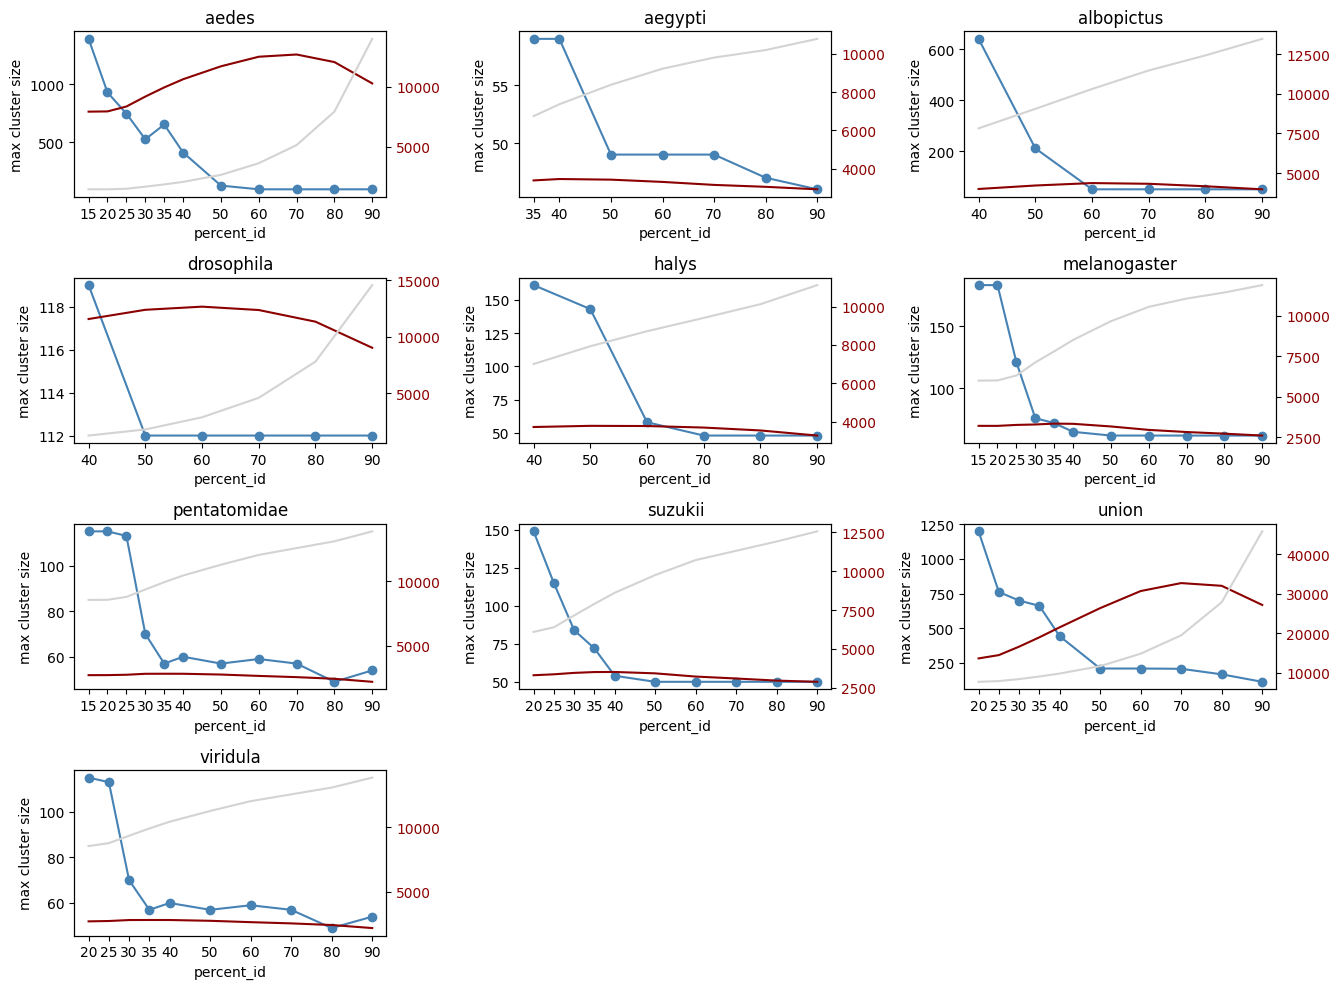

In [70]:
###################################### PARAMS
PLOT_W = 4.5
PLOT_H = 2.5
N_COLS = 3
MAIN_COLOR = 'steelblue'
LINE_COLOR = 'darkred'
LIGHT_GRAY = 'lightgray'

###################################### EXECUTION
clus_df['percent_id'] = pd.to_numeric(clus_df['percent_id'])
df_u = clus_df[['label', 'percent_id', 'cluster_rank', 'member_count']].drop_duplicates()

df_max = df_u.groupby(['label', 'percent_id'])['member_count'].max().rename('max_size')
df_gt1 = df_u[df_u['member_count'] > 1].groupby(['label', 'percent_id']).size().rename('gt1_count')
df_eq1 = df_u[df_u['member_count'] == 1].groupby(['label', 'percent_id']).size().rename('eq1_count')

df_agg = pd.concat([df_max, df_gt1, df_eq1], axis=1).fillna(0).reset_index()

labels = df_agg['label'].unique()
all_xticks = sorted(df_agg['percent_id'].unique())
n_rows = (len(labels) + N_COLS - 1) // N_COLS

fig, axes = plt.subplots(n_rows, N_COLS, figsize=(N_COLS * PLOT_W, n_rows * PLOT_H))
axes = axes.flatten()

for i, lbl in enumerate(labels):
    sub = df_agg[df_agg['label'] == lbl].sort_values('percent_id')
    
    # Main line hardcoded style with dots
    axes[i].plot(
        sub['percent_id'], 
        sub['max_size'], 
        color=MAIN_COLOR, 
        marker='o', 
        linestyle='-', 
        linewidth=1.5
    )
    axes[i].set_title(lbl)
    axes[i].set_xlabel('percent_id')
    axes[i].set_ylabel('max cluster size')
    axes[i].set_xticks(all_xticks)
    
    # Secondary axis lines
    ax2 = axes[i].twinx()
    ax2.plot(sub['percent_id'], sub['gt1_count'], color=LINE_COLOR)
    ax2.plot(sub['percent_id'], sub['eq1_count'], color=LIGHT_GRAY)
    ax2.tick_params(axis='y', labelcolor=LINE_COLOR)

for j in range(len(labels), len(axes)): 
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()